# Pre-entrega 2: Pipeline de Preprocesamiento y Diagnóstico

Este notebook prepara y diagnostica el corpus AG News para su uso posterior en modelos de clasificación. Se trabaja exclusivamente con el conjunto `train` para calcular estadísticas y se conserva `test` separado para la evaluación final.

In [11]:
import re
import html
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from matplotlib.backends.backend_pdf import PdfPages



## 1. Carga y verificación del dataset

Se cargan los archivos `ag_news_train.csv` y `ag_news_test.csv` mediante el script provisto. Se comprueban las dimensiones y las categorías disponibles antes de comenzar el análisis.

In [3]:
PROJECT_DIR = None
workspace_root = Path(r"u:\Curso_Data\Data Science III\proy_data_science_III")
candidates = [Path.cwd(), *Path.cwd().parents, workspace_root]
for candidate in candidates:
    if (candidate / "data" / "ag_news_train.csv").exists():
        PROJECT_DIR = candidate
        break
if PROJECT_DIR is None:
    raise FileNotFoundError("No se encontró data/ag_news_train.csv desde el directorio actual ni en la ruta del workspace.")

DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(DATA_DIR))
from cargar_dataset import cargar  # type: ignore[import-not-found]

train_df, test_df = cargar("ag_news")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print("Clases:", sorted(train_df["label"].unique()))

Train: (8000, 2) | Test: (2000, 2)
Clases: ['Business', 'Sci_Tech', 'Sports', 'World']


## 2. Configuración del modelo lingüístico

Se carga el modelo `en_core_web_sm` de SpaCy, necesario para tokenizar y lematizar el texto en inglés. También se obtiene el conjunto de stop-words que se utilizará para diagnosticar las 50 palabras más frecuentes.

In [4]:
# Setup de SpaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

STOP_WORDS = nlp.Defaults.stop_words
print(f"[*] SpaCy cargado. Stop-words disponibles: {len(STOP_WORDS)}")

[*] SpaCy cargado. Stop-words disponibles: 326


## 3. Limpieza, normalización y lematización

Se define el pipeline de texto: elimina HTML, URLs, números y caracteres no alfabéticos; convierte el texto a minúsculas y aplica lematización con SpaCy. El ejemplo final de la celda permite comprobar rápidamente el comportamiento de la función.

In [5]:
# Limpieza, normalización y lematización
HTML_TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    text = html.unescape(text)
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text.lower())
    return MULTI_SPACE_RE.sub(" ", text).strip()


def preprocess_text(text: str) -> str:
    doc = nlp(clean_text(text))
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space and not token.is_punct and len(token.lemma_) > 1
    )

sample = "<p>Stocks fell 3.5% on Monday, see http://example.com!</p>"
print(preprocess_text(sample))

stock fall on monday see


## 4. Aplicación del pipeline al corpus

Se aplica `preprocess_text` a los 8.000 documentos de entrenamiento y se crea la columna `text_processed`. El conjunto de prueba no se procesa ni se utiliza para calcular las estadísticas del EDA.

In [6]:
# Aplicación del pipeline únicamente sobre train para el EDA
train_df["text_processed"] = train_df["text"].astype(str).map(preprocess_text)
print(f"[*] Pipeline aplicado sobre {len(train_df)} documentos.")
train_df[["text", "text_processed", "label"]].head()

[*] Pipeline aplicado sobre 8000 documentos.


,text,text_processed,label
0,"Red Hat Appoints New CFO. September 2, 2004 --...",red hat appoint new cfo september web host ind...,Sci_Tech
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",sprint sbc in hotspot roam deal sprint and sbc...,Sci_Tech
2,Radio Outage Grounds West Coast Flights. Airpo...,radio outage ground west coast flights airport...,Business
3,Hollywood lawsuits to strike Net pirates. Holl...,hollywood lawsuit to strike net pirate hollywo...,Sci_Tech
4,Custis Takes Control. Family and Tony Robbins ...,custis take control family and tony robbin hav...,Sports


## 5. Distribución de longitud y percentil 95

Se cuenta la cantidad de tokens de cada noticia y se representa su distribución en un histograma. El percentil 95 se adopta como `max_len` de referencia para limitar el padding y la truncación en modelos posteriores.

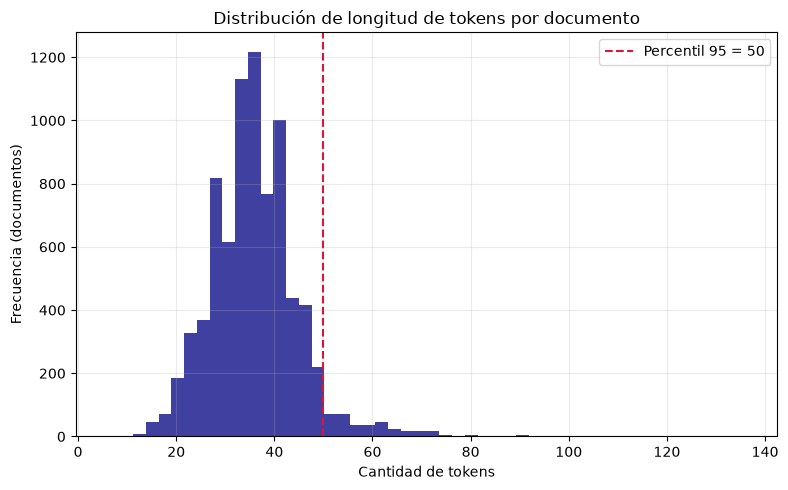

Media: 35.97 | Mediana: 36 | Percentil 95: 50


In [7]:
# Distribución de longitud de tokens y percentil 95
token_counts = train_df["text_processed"].str.split().map(len)
p95 = int(np.percentile(token_counts, 95))
max_len = p95

fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
ax_hist.hist(token_counts, bins=50, color="navy", alpha=0.75)
ax_hist.axvline(p95, color="crimson", linestyle="--", label=f"Percentil 95 = {p95}")
ax_hist.set_title("Distribución de longitud de tokens por documento")
ax_hist.set_xlabel("Cantidad de tokens")
ax_hist.set_ylabel("Frecuencia (documentos)")
ax_hist.legend()
ax_hist.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
print(f"Media: {token_counts.mean():.2f} | Mediana: {token_counts.median():.0f} | Percentil 95: {p95}")

## 6. Bi-gramas y tri-gramas

Se utiliza `CountVectorizer` para extraer las secuencias de dos y tres tokens más frecuentes. Estas tablas permiten identificar expresiones recurrentes y comprobar que la limpieza no dejó ruido textual.

In [8]:
# Top 20 bi-gramas y tri-gramas

def top_ngrams(corpus, ngram_range, top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    matrix = vectorizer.fit_transform(corpus)
    frequencies = matrix.sum(axis=0).A1
    vocabulary = vectorizer.get_feature_names_out()
    counts = sorted(zip(vocabulary, frequencies), key=lambda item: item[1], reverse=True)[:top_n]
    return pd.DataFrame(counts, columns=["ngram", "frecuencia"])


top_bigrams = top_ngrams(train_df["text_processed"], (2, 2))
top_trigrams = top_ngrams(train_df["text_processed"], (3, 3))
print("Top 20 bi-gramas:")
display(top_bigrams)
print("Top 20 tri-gramas:")
display(top_trigrams)

Top 20 bi-gramas:


,ngram,frecuencia
0,of the,1410
1,in the,1383
2,for the,610
3,ap ap,529
4,to the,485
5,on the,462
6,new york,419
7,at the,394
8,have be,333
9,the world,307


Top 20 tri-gramas:


,ngram,frecuencia
0,new york reuters,151
1,the united states,149
2,one of the,107
3,ap ap the,85
4,for the first,71
5,the first time,71
6,quote profile research,69
7,kill at least,57
8,be expect to,56
9,of the year,55


## 7. Frecuencia léxica y distribución de clases

Se calcula el top 50 de palabras y se identifica cuántas pertenecen al conjunto de stop-words de SpaCy. También se grafica la cantidad de noticias por categoría para evaluar el balance del corpus.

[*] De las top 50 palabras, 36 son stop-words estándar de SpaCy.


,palabra,frecuencia,es_stopword
0,the,13698,True
1,to,7976,True
2,of,6578,True
3,in,6365,True
4,be,4651,True
5,and,4637,True
6,on,3774,True
7,for,3410,True
8,have,2419,True
9,say,1976,True


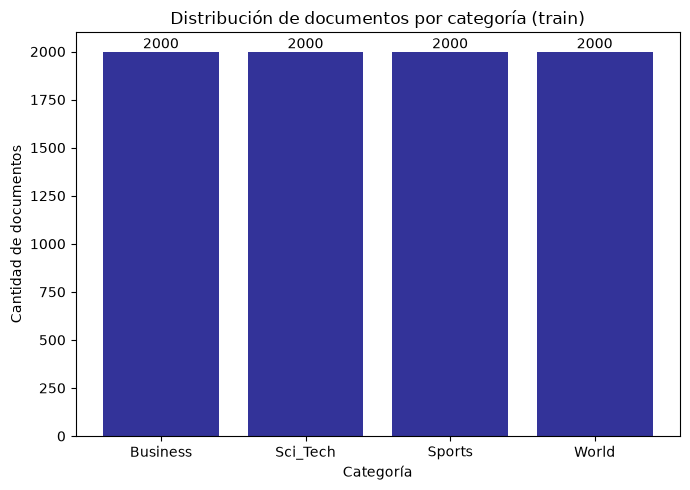

label
Business    2000
Sci_Tech    2000
Sports      2000
World       2000
Name: count, dtype: int64


In [9]:
# Top 50 palabras, stop-words y distribución de clases
all_tokens = " ".join(train_df["text_processed"]).split()
word_freq = Counter(all_tokens)
top50_df = pd.DataFrame(word_freq.most_common(50), columns=["palabra", "frecuencia"])
top50_df["es_stopword"] = top50_df["palabra"].isin(STOP_WORDS)
n_stopwords = int(top50_df["es_stopword"].sum())
print(f"[*] De las top 50 palabras, {n_stopwords} son stop-words estándar de SpaCy.")
display(top50_df)

class_counts = train_df["label"].value_counts().sort_index()
fig_classes, ax_classes = plt.subplots(figsize=(7, 5))
ax_classes.bar(class_counts.index.astype(str), class_counts.values, color="navy", alpha=0.8)
ax_classes.set_title("Distribución de documentos por categoría (train)")
ax_classes.set_xlabel("Categoría")
ax_classes.set_ylabel("Cantidad de documentos")
for index, value in enumerate(class_counts.values):
    ax_classes.text(index, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()
print(class_counts)

## 8. Generación del informe PDF

Se reúnen los resultados del EDA en un PDF: resumen del preprocesamiento, histograma, tablas de n-gramas, interpretaciones, distribución de clases y conclusión sobre la preparación del corpus.

In [10]:
# Generación del informe PDF final
from matplotlib.backends.backend_pdf import PdfPages
from textwrap import wrap

APELLIDO_NOMBRE = "TroncosoMarcelo"
PDF_PATH = DATA_DIR / f"EDA_NLP_{APELLIDO_NOMBRE}.pdf"
PDF_PATH.parent.mkdir(parents=True, exist_ok=True)

COLORS = {
    "ink": "#17202A",
    "muted": "#5D6D7E",
    "teal": "#0F766E",
    "blue": "#2563EB",
    "gold": "#D97706",
    "light": "#F4F7F8",
    "line": "#D5DBDB",
}

CONCLUSION_TEXT = (
    "AG News contiene noticias breves y presenta un balance perfecto entre sus cuatro clases: "
    "Business, Sci_Tech, Sports y World. Los principales desafíos del corpus son la variabilidad "
    "morfológica, la presencia potencial de URLs, etiquetas HTML, números y signos de puntuación, "
    "además de las diferencias de longitud entre documentos. El pipeline aborda estos problemas en "
    "un orden reproducible: primero decodifica entidades HTML y elimina ruido estructural; luego "
    "normaliza a minúsculas, conserva únicamente caracteres alfabéticos y aplica lematización con "
    "SpaCy. El histograma y el percentil 95 permiten elegir un max_len basado en los datos, evitando "
    "padding excesivo y truncaciones arbitrarias. Los bi-gramas y tri-gramas muestran patrones "
    "periodísticos útiles y no evidencian residuos HTML o URLs. En consecuencia, el corpus queda "
    "preparado para vectorización y modelado. Como el conjunto de prueba se mantiene separado, las "
    "estadísticas obtenidas no contaminan la evaluación posterior."
 )

def style_axis(axis):
    axis.set_facecolor("white")
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.tick_params(colors=COLORS["muted"], labelsize=9)

def add_header(figure, title, subtitle=None):
    figure.text(0.07, 0.94, title, fontsize=19, fontweight="bold", color=COLORS["ink"], va="top")
    if subtitle:
        figure.text(0.07, 0.905, subtitle, fontsize=9.5, color=COLORS["muted"], va="top")
    figure.lines.append(plt.Line2D([0.07, 0.93], [0.885, 0.885], transform=figure.transFigure, color=COLORS["teal"], linewidth=2))

def add_text_page(pdf, title, paragraphs, subtitle=None):
    figure = plt.figure(figsize=(8.27, 11.69), facecolor="white")
    add_header(figure, title, subtitle)
    y_position = 0.82
    for paragraph in paragraphs:
        lines = wrap(paragraph, width=92)
        figure.text(0.08, y_position, "\n".join(lines), fontsize=11, color=COLORS["ink"], va="top", linespacing=1.55)
        y_position -= 0.06 + 0.027 * len(lines)
    pdf.savefig(figure)
    plt.close(figure)

def add_table_page(pdf, title, dataframe, subtitle):
    figure, axis = plt.subplots(figsize=(8.27, 11.69), facecolor="white")
    axis.axis("off")
    add_header(figure, title, subtitle)
    table = axis.table(
        cellText=dataframe.values,
        colLabels=dataframe.columns,
        colWidths=[0.62, 0.22] if len(dataframe.columns) == 2 else [0.48, 0.20, 0.20],
        loc="center",
        cellLoc="left",
        colLoc="left",
        bbox=[0.04, 0.12, 0.92, 0.68],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor(COLORS["line"])
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor(COLORS["teal"])
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("#F7F9F9" if row % 2 == 0 else "white")
            cell.set_text_props(color=COLORS["ink"])
    pdf.savefig(figure)
    plt.close(figure)

def add_chart_page(pdf, title, chart_figure, subtitle):
    chart_figure.set_size_inches(8.27, 11.69)
    chart_figure.subplots_adjust(top=0.78, bottom=0.16, left=0.12, right=0.95)
    chart_figure.text(0.07, 0.94, title, fontsize=19, fontweight="bold", color=COLORS["ink"], va="top")
    chart_figure.text(0.07, 0.90, subtitle, fontsize=9.5, color=COLORS["muted"], va="top")
    chart_figure.lines.append(plt.Line2D([0.07, 0.93], [0.875, 0.875], transform=chart_figure.transFigure, color=COLORS["teal"], linewidth=2))
    pdf.savefig(chart_figure)
    plt.close(chart_figure)

with PdfPages(PDF_PATH) as pdf:
    metadata = pdf.infodict()
    metadata["Title"] = "EDA NLP - AG News"
    metadata["Author"] = APELLIDO_NOMBRE
    metadata["Subject"] = "Informe técnico de preprocesamiento y diagnóstico"

    cover = plt.figure(figsize=(8.27, 11.69), facecolor="white")
    cover.text(0.08, 0.78, "INFORME TÉCNICO", fontsize=13, color=COLORS["teal"], weight="bold", va="top")
    cover.text(0.08, 0.69, "EDA_NLP_TroncosoMarcelo.pdf", fontsize=20, color=COLORS["ink"], weight="bold", va="top")
    cover.text(0.08, 0.57, "Análisis exploratorio del corpus AG News", fontsize=15, color=COLORS["ink"], va="top")
    cover.text(0.08, 0.50, "Pipeline de limpieza, normalización, lematización y diagnóstico estadístico", fontsize=10.5, color=COLORS["muted"], va="top")
    cover.lines.append(plt.Line2D([0.08, 0.92], [0.44, 0.44], transform=cover.transFigure, color=COLORS["teal"], linewidth=2))
    cover.text(0.08, 0.12, "Proyecto Integrador · Deep Learning", fontsize=10, color=COLORS["muted"], va="bottom")
    cover.text(0.92, 0.12, "Pre-entrega 2", fontsize=10, color=COLORS["muted"], va="bottom", ha="right")
    pdf.savefig(cover)
    plt.close(cover)

    add_text_page(pdf, "Resumen del análisis", [
        "Dataset analizado: AG News, con 8.000 documentos de entrenamiento y 2.000 documentos de prueba. El EDA se calcula exclusivamente sobre train para preservar la independencia del conjunto test.",
        "Preprocesamiento aplicado: decodificación de entidades HTML, eliminación de etiquetas y URLs, conversión a minúsculas, eliminación de caracteres no alfabéticos, tokenización y lematización con SpaCy.",
        f"Resultado principal: longitud media de {token_counts.mean():.2f} tokens, mediana de {token_counts.median():.0f} y percentil 95 igual a {p95}. El valor p95 se propone como max_len de referencia.",
        f"Las cuatro clases están balanceadas con {int(class_counts.iloc[0])} documentos cada una. En el top 50 léxico se identificaron {n_stopwords} stop-words estándar de SpaCy.",
    ], "Resumen ejecutivo del pipeline y de los principales hallazgos")

    chart_hist = plt.figure(figsize=(8.27, 11.69), facecolor="white")
    axis_hist = chart_hist.add_subplot(111)
    axis_hist.hist(token_counts, bins=45, color=COLORS["blue"], alpha=0.82, edgecolor="white")
    axis_hist.axvline(p95, color=COLORS["gold"], linestyle="--", linewidth=2, label=f"Percentil 95 = {p95}")
    axis_hist.set_xlabel("Cantidad de tokens por documento", color=COLORS["muted"])
    axis_hist.set_ylabel("Cantidad de documentos", color=COLORS["muted"])
    axis_hist.legend(frameon=False, loc="upper right")
    axis_hist.grid(axis="y", alpha=0.18)
    style_axis(axis_hist)
    add_chart_page(pdf, "Distribución de longitud de tokens", chart_hist, "Histograma del corpus train después del preprocesamiento")

    add_table_page(pdf, "20 bi-gramas más frecuentes", top_bigrams, "Secuencias de dos tokens y frecuencia de aparición")
    add_text_page(pdf, "Interpretación de bi-gramas", [
        "Los bi-gramas permiten observar asociaciones frecuentes del lenguaje periodístico, como nombres de organizaciones, lugares, actores políticos o términos deportivos. Su análisis sirve como control de calidad: después de la limpieza no deberían dominar etiquetas HTML, URLs ni símbolos aislados.",
    ], "Lectura breve de los patrones léxicos encontrados")

    add_table_page(pdf, "20 tri-gramas más frecuentes", top_trigrams, "Secuencias de tres tokens y frecuencia de aparición")
    add_text_page(pdf, "Interpretación de tri-gramas", [
        "Los tri-gramas agregan contexto y suelen representar expresiones periodísticas más específicas. Pueden aportar señales para diferenciar las categorías temáticas de AG News, especialmente cuando combinan entidades, acciones y conceptos propios de cada sección.",
    ], "Lectura breve de los patrones contextuales encontrados")

    chart_classes = plt.figure(figsize=(8.27, 11.69), facecolor="white")
    axis_classes = chart_classes.add_subplot(111)
    bars = axis_classes.bar(class_counts.index.astype(str), class_counts.values, color=[COLORS["teal"], COLORS["blue"], COLORS["gold"], "#7C3AED"], width=0.62)
    axis_classes.set_xlabel("Categoría", color=COLORS["muted"])
    axis_classes.set_ylabel("Cantidad de documentos", color=COLORS["muted"])
    axis_classes.set_ylim(0, max(class_counts.values) * 1.15)
    axis_classes.grid(axis="y", alpha=0.18)
    for bar in bars:
        axis_classes.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, f"{int(bar.get_height()):,}", ha="center", va="bottom", color=COLORS["ink"], fontsize=10, weight="bold")
    style_axis(axis_classes)
    add_chart_page(pdf, "Distribución de clases", chart_classes, "Cantidad de documentos por categoría en el conjunto train")

    add_text_page(pdf, "Conclusión", [CONCLUSION_TEXT], "Preparación del corpus para el modelo final")

print(f"[*] PDF generado en: {PDF_PATH.resolve()}")

[*] PDF generado en: U:\Curso_Data\Data Science III\proy_data_science_III\data\EDA_NLP_TroncosoMarcelo.pdf
